# **1. Import semua modul Library yang dibutuhkan**

In [379]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, average_precision_score
from sklearn.preprocessing import StandardScaler

# **2. Import Dataset**

In [380]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Comvis - Citra Otak/Brain_Tumor.csv")
print((df.iloc[:,0:7].head()).to_string())
print((df.iloc[:,8:15].head()).to_string())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    Image  Class      Mean     Variance  Standard Deviation   Entropy  Skewness
0  Image1      0  6.535339   619.587845           24.891522  0.109059  4.276477
1  Image2      0  8.749969   805.957634           28.389393  0.266538  3.718116
2  Image3      1  7.341095  1143.808219           33.820234  0.001467  5.061750
3  Image4      1  5.958145   959.711985           30.979219  0.001477  5.677977
4  Image5      0  7.315231   729.540579           27.010009  0.146761  4.283221
     Contrast    Energy       ASM  Homogeneity  Dissimilarity  Correlation     Coarseness
0   98.613971  0.293314  0.086033     0.530941       4.473346     0.981939  7.458341e-155
1   63.858816  0.475051  0.225674     0.651352       3.220072     0.988834  7.458341e-155
2   81.867206  0.031917  0.001019     0.268275       5.981800     0.978014  7.458341e-155
3  151.229741  0.032024  0.0010

# **3. Data Cleansing, Cek ada tidaknya nilai null pada dataset**

In [381]:
print (df.isnull().sum())

Image                 0
Class                 0
Mean                  0
Variance              0
Standard Deviation    0
Entropy               0
Skewness              0
Kurtosis              0
Contrast              0
Energy                0
ASM                   0
Homogeneity           0
Dissimilarity         0
Correlation           0
Coarseness            0
dtype: int64


# **4. Baca informasi terkait dataset**

In [382]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Image               3762 non-null   object 
 1   Class               3762 non-null   int64  
 2   Mean                3762 non-null   float64
 3   Variance            3762 non-null   float64
 4   Standard Deviation  3762 non-null   float64
 5   Entropy             3762 non-null   float64
 6   Skewness            3762 non-null   float64
 7   Kurtosis            3762 non-null   float64
 8   Contrast            3762 non-null   float64
 9   Energy              3762 non-null   float64
 10  ASM                 3762 non-null   float64
 11  Homogeneity         3762 non-null   float64
 12  Dissimilarity       3762 non-null   float64
 13  Correlation         3762 non-null   float64
 14  Coarseness          3762 non-null   float64
dtypes: float64(13), int64(1), object(1)
memory usage: 441.0

# **5. Baca Deskripsi Statistik Dataset**

In [383]:
print(df.describe().to_string())

             Class         Mean     Variance  Standard Deviation      Entropy     Skewness     Kurtosis     Contrast       Energy          ASM  Homogeneity  Dissimilarity  Correlation     Coarseness
count  3762.000000  3762.000000  3762.000000         3762.000000  3762.000000  3762.000000  3762.000000  3762.000000  3762.000000  3762.000000  3762.000000    3762.000000  3762.000000   3.762000e+03
mean      0.447368     9.488890   711.101063           25.182271     0.073603     4.102727    24.389071   127.961459     0.204705     0.058632     0.479252       4.698498     0.955767  7.458341e-155
std       0.497288     5.728022   467.466896            8.773526     0.070269     2.560940    56.434747   109.499601     0.129352     0.058300     0.127929       1.850173     0.026157   0.000000e+00
min       0.000000     0.078659     3.145628            1.773592     0.000882     1.886014     3.942402     3.194733     0.024731     0.000612     0.105490       0.681121     0.549426  7.458341e-155
25%  

# **6. Skalakan Data untuk meminimalisir error Prediksi**

In [384]:
scalable = ['Mean','Variance', 'Standard Deviation','Entropy', 'Skewness', 'Kurtosis', 'Contrast',\
            'ASM', 'Homogeneity','Dissimilarity','Correlation','Coarseness']

df[scalable] = StandardScaler().fit_transform(df[scalable])

print(df.describe().iloc[:,0:5].to_string())
print(df.describe().iloc[:,6:11].to_string())
print(df.describe().iloc[:,12:15].to_string())

             Class          Mean      Variance  Standard Deviation       Entropy
count  3762.000000  3.762000e+03  3.762000e+03        3.762000e+03  3.762000e+03
mean      0.447368  1.435440e-16 -1.284341e-16        2.946429e-16 -1.813187e-16
std       0.497288  1.000133e+00  1.000133e+00        1.000133e+00  1.000133e+00
min       0.000000 -1.643060e+00 -1.514652e+00       -2.668459e+00 -1.035037e+00
25%       0.000000 -7.868500e-01 -7.442706e-01       -6.980786e-01 -9.499968e-01
50%       0.000000 -1.765868e-01 -1.893876e-01       -2.629972e-02 -9.926889e-02
75%       1.000000  6.501944e-01  5.473912e-01        6.741194e-01  5.647895e-01
max       1.000000  4.147024e+00  4.705730e+00        3.279339e+00  4.567876e+00
           Kurtosis      Contrast       Energy           ASM   Homogeneity
count  3.762000e+03  3.762000e+03  3762.000000  3.762000e+03  3.762000e+03
mean  -7.554947e-18  7.554947e-17     0.204705  3.021979e-17 -4.230770e-16
std    1.000133e+00  1.000133e+00     0.129352

# **7. Menampilkan Distribusi Variabel Target (Class)**

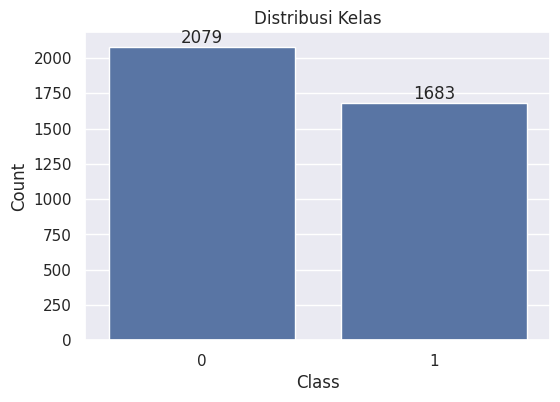

Number of Tumor Samples: 1683
Tumor Percentage: 44.74 %
Number of No Tumor Samples: 2079
No Tumor Percentage: 55.26 %


In [385]:
plt.figure(figsize=(6,4))
sns.set_style("darkgrid")

ax = sns.countplot(x='Class', data=df)

# Menambahkan label angka di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Distribusi Kelas")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

print('Number of Tumor Samples:', df['Class'].value_counts()[1])
print ('Tumor Percentage:', round(df['Class'].value_counts()[1]/len(df)*100,2),'%')

print('Number of No Tumor Samples:', df['Class'].value_counts()[0])
print ('No Tumor Percentage:', round(df['Class'].value_counts()[0]/len(df)*100,2),'%')

# **8. Fitur Homogeneity berdasarkan Class**

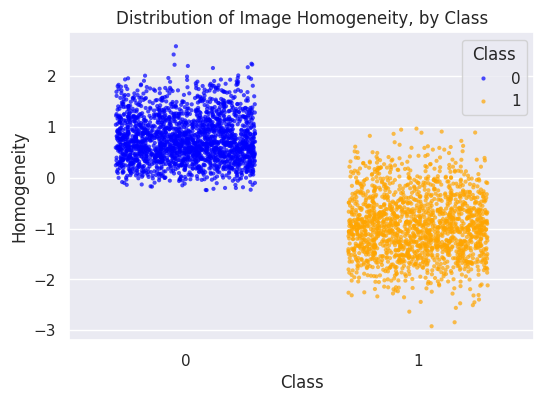

In [386]:
plt.figure(figsize=(6,4))
sns.set_style("darkgrid")

sns.stripplot(
    x='Class',
    y='Homogeneity',
    data=df,
    hue='Class',              # membedakan warna berdasarkan class
    palette=['blue', 'orange'],
    jitter=0.3,
    size=3,
    alpha=0.7,
    dodge=False
)

plt.title('Distribution of Image Homogeneity, by Class')
plt.xlabel('Class')
plt.ylabel('Homogeneity')
plt.show()

# **9. Menampilkan Distribusi fitur Mean vs Entropy vs Class**

<Axes: xlabel='Mean', ylabel='Entropy'>

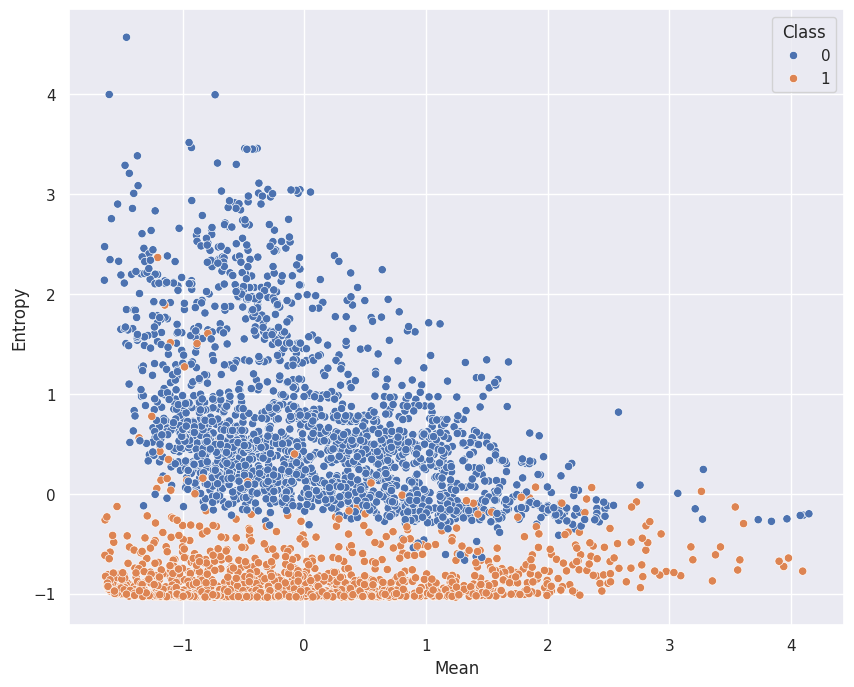

In [387]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Mean', y='Entropy', hue='Class', data=df)

# **10. Distribusi fitur Energy berdasarkan Class dan distribusi fitur Entropy berdasarkan Class**

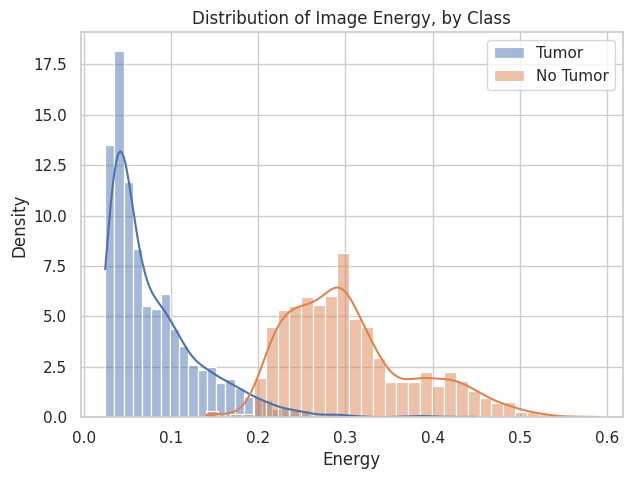

In [388]:
sns.set_style("whitegrid")

# Pisahkan data
class1 = df['Class'] == 1   # Tumor
class0 = df['Class'] == 0   # No Tumor

# Drop kolom yang tidak perlu
_data = df.drop('Image', axis=1)

# Figure
plt.figure(figsize=(7,5))

# Histogram + KDE untuk Tumor
sns.histplot(_data[class1]['Energy'],
             kde=True,
             stat="density",
             label="Tumor",
             alpha=0.5)

# Histogram + KDE untuk No Tumor
sns.histplot(_data[class0]['Energy'],
             kde=True,
             stat="density",
             label="No Tumor",
             alpha=0.5)

# Judul & label
plt.title("Distribution of Image Energy, by Class")
plt.xlabel("Energy")
plt.ylabel("Density")

# Legend
plt.legend()

plt.show()

# **11. Pemisahan Data (Data Splitting)**

In [389]:
# Menentukan fitur (X) dan target (y)
# Sesuai dengan penelitian, kita menggunakan fitur tekstur hasil ekstraksi
X = df.drop(['Image', 'Class'], axis=1)
y = df['Class']

# Membagi data menjadi 80% Train dan 20% Test (umum digunakan dalam riset)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=9)

# Menyiapkan data khusus untuk visualisasi Decision Boundary (2 fitur saja)
# Kita gunakan Homogeneity dan Skewness sesuai kode Anda sebelumnya
X_train_feature = X_train[['Homogeneity', 'Skewness']]
X_test_feature = X_test[['Homogeneity', 'Skewness']]
y_train_feature = Y_train
y_test_feature = Y_test

# **12. Visualisasi Perbandingan Nilai Prediksi dan Nilai Aktual**

In [390]:
def plot_real_pred_val(y_true, y_pred, title):
    import matplotlib.pyplot as plt
    from sklearn.metrics import accuracy_score

    plt.figure(figsize=(10,5))

    plt.scatter(range(len(y_pred)), y_pred,
                color='blue', label='Predicted', s=20, alpha=0.6)

    plt.scatter(range(len(y_true)), y_true,
                color='red', label='Actual', s=20, alpha=0.8)

    plt.title(f'Prediction Values vs Real Values of {title}')
    plt.xlabel("Data Index")
    plt.ylabel("Class")

    acc = accuracy_score(y_true, y_pred)
    plt.text(0, -0.1, f'Accuracy: {acc*100:.3f}%', fontsize=10)

    plt.legend()
    plt.show()

# **13. Fungsi Visualisasi**

In [391]:
knncla = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knncla.fit(X_train, Y_train)

KNeighborsClassifier(n_jobs=-1)

# **14. Split Data**

In [392]:
pred_knn = knncla.predict(X_test)
print(pred_knn[:100])

[1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 0 0 1 1 0 0 1
 1 0 0 0 1 0 1 0 0 0 1 1 0 1 0 1 0 1 1 0 0 0 1 0 1 1 1 1 1 0 0 0 1 0 0 1 0
 1 0 1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1]


# **15. Model KNN**

In [393]:
score_knncla = knncla.score(X_test, Y_test)
print(score_knncla)

average_precision_score_knn = average_precision_score(Y_test, pred_knn)
print(average_precision_score_knn)

0.9867197875166003
0.9811610785767257


# **16. Visualisasi**

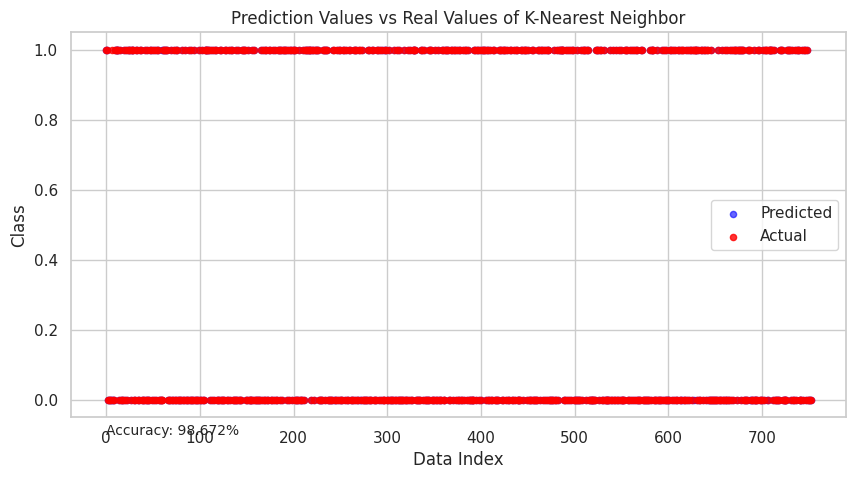

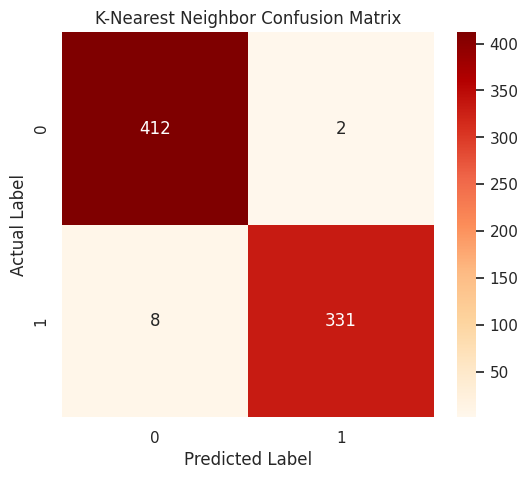

In [394]:
plot_real_pred_val(Y_test, pred_knn, "K-Nearest Neighbor")
plot_cm(Y_test, pred_knn, "K-Nearest Neighbor")

# **17. Ambil 2 Fitur Decision Boundary**

In [395]:
knncla_feat = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knncla_feat.fit(X_train_feature, y_train_feature)

KNeighborsClassifier(n_jobs=-1)

# **18. Split data (2 fitur)**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but KNeighborsClassifier was fitted with feature names



<Axes: >

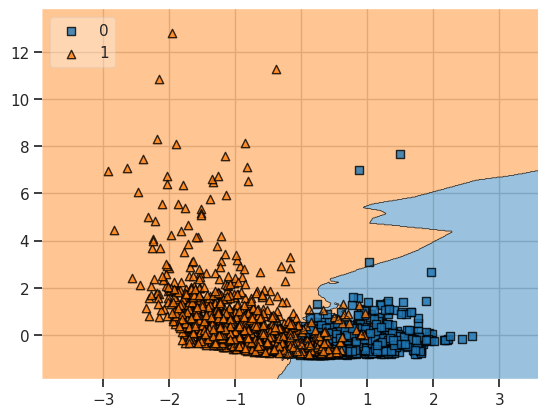

In [396]:
plot_decision_regions(
    X_train_feature.values,
    y_train_feature.values,
    clf=knncla_feat,
    legend=2
)

# **19. KNN 2 fitur**

In [397]:
pred_knn_feat = knncla_feat.predict(X_test_feature)
print(pred_knn_feat[:100])

score_knncla_feat = knncla_feat.score(X_test_feature, y_test_feature)
print(score_knncla_feat)

[1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 0 1 1 0 0 1
 1 0 0 0 1 1 1 0 0 0 1 1 0 1 0 1 0 1 1 0 0 0 1 0 1 1 1 1 1 0 0 0 1 0 0 1 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 0 1 0 0 0 0 1]
0.9455511288180611
